# Лабораторная работа №3: Линейная регрессия

## Задание 1.1.1

**Условие задачи:**

На основе экспериментальных данных, представленных значениями x=[1,2,3,4,5]  
и y=[2,3.5,5,6.5,8], постройте модель парной линейной регрессии вида y=mx+c 
методом наименьших квадратов. Вычислите коэффициенты m и c, визуализируйте 
исходные точки и полученную линию регрессии на одном графике.

m = 1.500, c = 0.500
Уравнение: y = 1.500x + 0.500


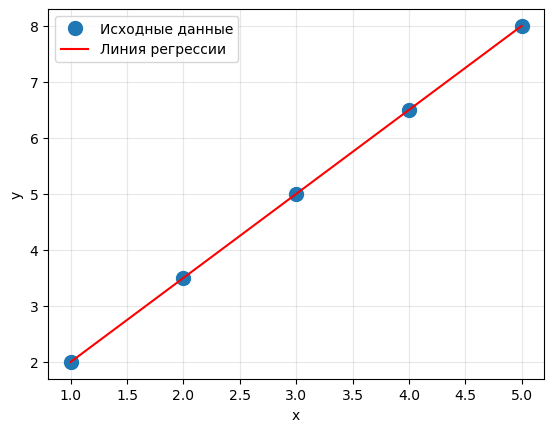

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Данные
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 3.5, 5, 6.5, 8])

# Формируем матрицу A: первый столбец x, второй - единицы
A = np.vstack([x, np.ones(len(x))]).T

# Метод наименьших квадратов
m, c = np.linalg.lstsq(A, y, rcond=None)[0]

print(f"m = {m:.3f}, c = {c:.3f}")
print(f"Уравнение: y = {m:.3f}x + {c:.3f}")

# Визуализация
plt.plot(x, y, 'o', label='Исходные данные', markersize=10)
plt.plot(x, m*x + c, 'r', label='Линия регрессии')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Задание 1.1.2

**Условие задачи:**

На реальных данных из набора в приложении (в соответствии со своим 
вариантом) построить модель линейной регрессии $y = ax + b + \epsilon$, оценив 
оптимальные параметры a и b из условия минимизации суммы квадратов 
отклонений для заданных значений признаков. Вычислить коэффициент 
детерминации для получившейся модели. Визуализировать на одном графике 
точки ($x_i$, $y_i$) и прямую y = ax + b. 

m = 1.1063
c = -1.6528
Уравнение: G3 = 1.1063 * G1 + (-1.6528)
R^2 = 0.6424
R^2 (sklearn): 0.6424


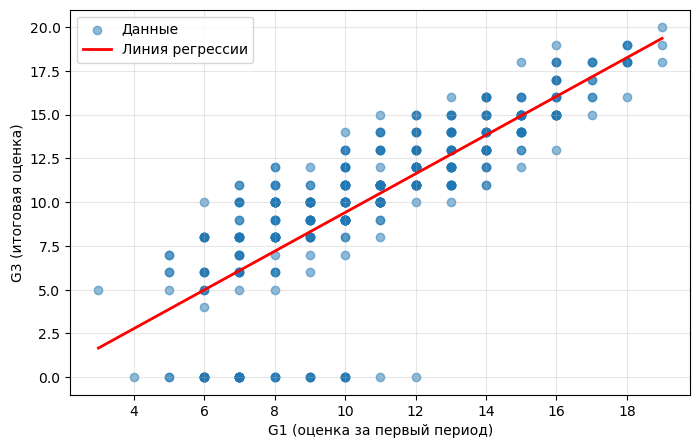

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import urllib.request
from io import BytesIO
import zipfile

# Загрузка датасета напрямую из ZIP-архива в память
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip"
response = urllib.request.urlopen(url)
zip_file = zipfile.ZipFile(BytesIO(response.read()))
df = pd.read_csv(zip_file.open('student-mat.csv'), sep=';')

# Предиктор и целевая переменная
X = df['G1'].values
y = df['G3'].values

# Метод наименьших квадратов
n = len(X)
x_mean = np.mean(X)
y_mean = np.mean(y)

m = np.sum((X - x_mean) * (y - y_mean)) / np.sum((X - x_mean)**2)
c = y_mean - m * x_mean

y_pred = m * X + c

# Коэффициент детерминации
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - y_mean)**2)
r2 = 1 - ss_res / ss_tot

print(f"m = {m:.4f}")
print(f"c = {c:.4f}")
print(f"Уравнение: G3 = {m:.4f} * G1 + ({c:.4f})")
print(f"R^2 = {r2:.4f}")
print(f"R^2 (sklearn): {r2_score(y, y_pred):.4f}")

# Визуализация
plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.5, label='Данные')
x_line = np.linspace(X.min(), X.max(), 100)
plt.plot(x_line, m * x_line + c, 'r', linewidth=2, label='Линия регрессии')
plt.xlabel('G1 (оценка за первый период)')
plt.ylabel('G3 (итоговая оценка)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Задание 1.1.3

**Условие задачи:**

Используя предоставленный датасет согласно вашему варианту, выполните 
регрессионный анализ для предсказания целевой переменной.  
Разделите данные на обучающую (80%) и тестовую (20%) выборки, 
постройте модель линейной регрессии, оцените её качество с помощью 
коэффициента детерминации $R^2$ и средней квадратичной ошибки MSE. 
Также визуализируйте фактические и предсказанные значения для тестовой 
выборки. 

b (intercept) = -2.0239
m (slope) = 1.1295
Уравнение: G3 = 1.1295 * G1 + (-2.0239)

MSE (тест) = 6.1627
R^2 (тест) = 0.6995

Первые 10 строк сравнения:
   Фактические  Предсказанные
0           10           7.01
1           12          13.79
2            5           1.36
3           10           7.01
4            9           8.14
5           13          11.53
6           18          19.44
7            6           8.14
8            0           7.01
9           14          10.40


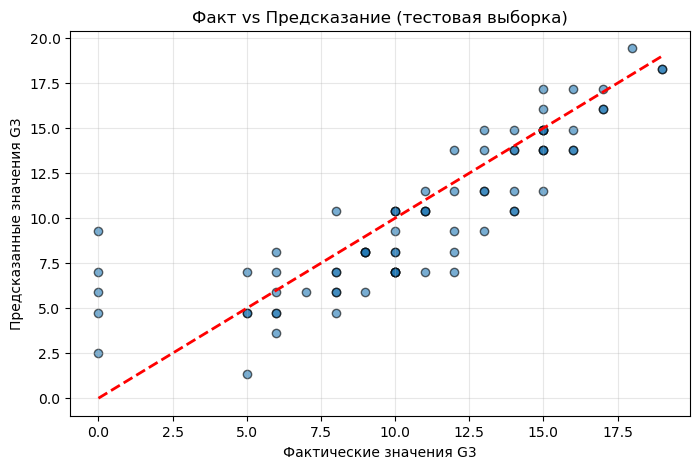

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import urllib.request
from io import BytesIO
import zipfile

# Загрузка датасета напрямую из ZIP-архива в память
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip"
response = urllib.request.urlopen(url)
zip_file = zipfile.ZipFile(BytesIO(response.read()))
df = pd.read_csv(zip_file.open('student-mat.csv'), sep=';')

# Предиктор и целевая переменная
X = df[['G1']].values  # двумерный массив для sklearn
y = df['G3'].values

# Разделение на обучающую (80%) и тестовую (20%) выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Обучение модели
model = LinearRegression()
model.fit(X_train, y_train)

# Коэффициенты
b = model.intercept_
m = model.coef_[0]
print(f"b (intercept) = {b:.4f}")
print(f"m (slope) = {m:.4f}")
print(f"Уравнение: G3 = {m:.4f} * G1 + ({b:.4f})")

# Предсказание на тестовой выборке
y_pred = model.predict(X_test)

# Оценка качества
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"\nMSE (тест) = {mse:.4f}")
print(f"R^2 (тест) = {r2:.4f}")

# Сравнение фактических и предсказанных значений
df_result = pd.DataFrame({'Фактические': y_test, 'Предсказанные': np.round(y_pred, 2)})
print("\nПервые 10 строк сравнения:")
print(df_result.head(10))

# Визуализация: фактические vs предсказанные
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Фактические значения G3')
plt.ylabel('Предсказанные значения G3')
plt.title('Факт vs Предсказание (тестовая выборка)')
plt.grid(True, alpha=0.3)
plt.show()

## Задание 1.2.1

**Условие задачи:**

Сгенерируйте синтетический датасет из 100 наблюдений с тремя 
признаками X1, X2, X3, распределенными нормально. Создайте целевую 
переменную по формуле Y=3X1−2X2+0.5X3+ε, где ε — случайный шум.  
Постройте модель множественной линейной регрессии и сравните 
полученные коэффициенты с истинными значениями. 

In [42]:
import numpy as np
from sklearn.linear_model import LinearRegression

np.random.seed(42)
n = 100

# Генерация признаков
X1 = np.random.normal(0, 1, n)
X2 = np.random.normal(0, 1, n)
X3 = np.random.normal(0, 1, n)
eps = np.random.normal(0, 1, n)

# Целевая переменная
Y = 3 * X1 - 2 * X2 + 0.5 * X3 + eps

# Матрица признаков
X = np.column_stack([X1, X2, X3])

# Модель
model = LinearRegression()
model.fit(X, Y)

# Сравнение коэффициентов
print("Истинные коэффициенты: [3.0, -2.0, 0.5]")
print(f"Оценённые коэффициенты: {np.round(model.coef_, 3)}")
print(f"Intercept: {model.intercept_:.3f}")
print(f"R^2: {model.score(X, Y):.3f}")

Истинные коэффициенты: [3.0, -2.0, 0.5]
Оценённые коэффициенты: [ 2.823 -2.038  0.527]
Intercept: 0.088
R^2: 0.944


## Задание 1.2.2

**Условие задачи:**

На основе датасета из вашего варианта постройте модель множественной 
линейной регрессии, используя не менее четырех признаков для предсказания 
целевой переменной (признаки выбираются самостоятельно).  
Оцените вклад каждого признака в модель, проанализируйте знаки и 
величины полученных коэффициентов.  
Вычислите коэффициент детерминации $R^2$ и среднюю квадратичную 
ошибку MSE.  
Визуализируйте фактические и предсказанные значения. Сделайте вывод о 
том, какие факторы оказывают наибольшее положительное и отрицательное 
влияние на целевую переменную. 

Признаки: ['G1', 'G2', 'age', 'absences', 'failures', 'studytime']
Размерность X: (395, 6)
Размерность y: (395,)

Коэффициенты модели (отсортированы по вкладу):
  Признак  Коэффициент  Вклад
       G2       0.9640 0.9640
 failures      -0.3826 0.3826
      age      -0.1754 0.1754
       G1       0.1627 0.1627
studytime      -0.0566 0.0566
 absences       0.0432 0.0432

Свободный член (intercept): 1.2036

MSE (тест): 4.4621
R^2 (тест): 0.7824

Вывод о влиянии признаков:
  • G2: коэффициент = 0.9640 — положительное влияние
  • failures: коэффициент = -0.3826 — отрицательное влияние
  • age: коэффициент = -0.1754 — отрицательное влияние
  • G1: коэффициент = 0.1627 — положительное влияние
  • studytime: коэффициент = -0.0566 — отрицательное влияние
  • absences: коэффициент = 0.0432 — положительное влияние

Наибольшее положительное влияние: G2 (коэф. = 0.9640)
Наибольшее отрицательное влияние: failures (коэф. = -0.3826)


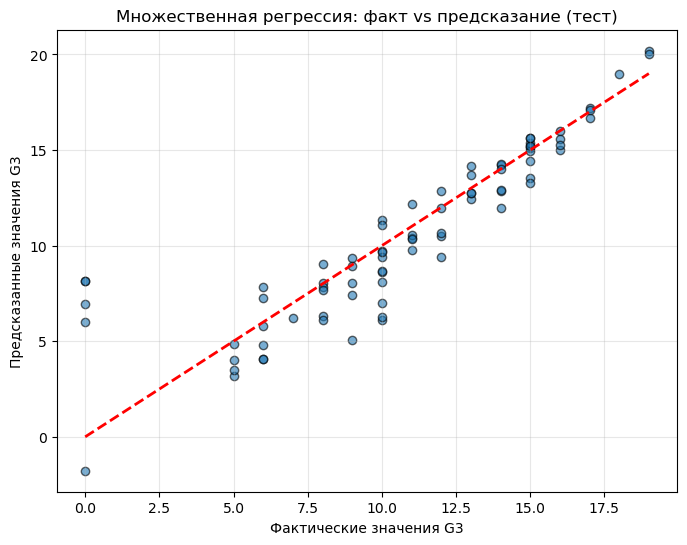

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import urllib.request
from io import BytesIO
import zipfile

# Загрузка датасета из ZIP-архива в память
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip"
response = urllib.request.urlopen(url)
zip_file = zipfile.ZipFile(BytesIO(response.read()))
df = pd.read_csv(zip_file.open('student-mat.csv'), sep=';')

# Выбор признаков (не менее 4-х)
features = ['G1', 'G2', 'age', 'absences', 'failures', 'studytime']
X = df[features].values
y = df['G3'].values

print(f"Признаки: {features}")
print(f"Размерность X: {X.shape}")
print(f"Размерность y: {y.shape}")

# Разделение на train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Обучение модели множественной регрессии
model = LinearRegression()
model.fit(X_train, y_train)

# Коэффициенты и вклад признаков
coef_df = pd.DataFrame({
    'Признак': features,
    'Коэффициент': np.round(model.coef_, 4)
})
coef_df['Вклад'] = coef_df['Коэффициент'].abs()
coef_df = coef_df.sort_values('Вклад', ascending=False)

print("\nКоэффициенты модели (отсортированы по вкладу):")
print(coef_df.to_string(index=False))
print(f"\nСвободный член (intercept): {model.intercept_:.4f}")

# Оценка качества
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nMSE (тест): {mse:.4f}")
print(f"R^2 (тест): {r2:.4f}")

# Вывод о влиянии признаков
print("\nВывод о влиянии признаков:")
for _, row in coef_df.iterrows():
    name = row['Признак']
    coef = row['Коэффициент']
    if coef > 0:
        direction = "положительное"
    else:
        direction = "отрицательное"
    print(f"  • {name}: коэффициент = {coef:.4f} — {direction} влияние")

max_positive = coef_df.loc[coef_df['Коэффициент'].idxmax()]
max_negative = coef_df.loc[coef_df['Коэффициент'].idxmin()]
print(f"\nНаибольшее положительное влияние: {max_positive['Признак']} (коэф. = {max_positive['Коэффициент']:.4f})")
print(f"Наибольшее отрицательное влияние: {max_negative['Признак']} (коэф. = {max_negative['Коэффициент']:.4f})")

# Визуализация: факт vs предсказание
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Фактические значения G3')
plt.ylabel('Предсказанные значения G3')
plt.title('Множественная регрессия: факт vs предсказание (тест)')
plt.grid(True, alpha=0.3)
plt.show()

## Задание 1.2.3

**Условие задачи:**

Сгенерируйте синтетический датасет из 150 наблюдений с пятью 
признаками X₁–X₅, из которых только три действительно влияют на целевую 
переменную, а два — шумовые (неинформативные). 
Пример формулы: Y = 4.2 X₁ + 1.8 X₃ – 2.7 X₅ + ε (признаки X₂ и X₄ — 
случайный шум, не связанный с Y). 
Постройте модель множественной линейной регрессии на всех пяти 
признаках. 
Проанализируйте: 
- какие коэффициенты получились близкими к нулю или статистически 
незначимыми, 
- как изменился R² по сравнению с моделью, построенной только на 
трёх информативных признаках, 
- как ведут себя предсказания при наличии «лишних» признаков 
(переобучение / стабильность коэффициентов). 
Сделайте вывод о влиянии неинформативных (шумовых) признаков на 
качество и интерпретируемость модели.  

In [5]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

# Генерация синтетического датасета
np.random.seed(123)
n = 150

# Признаки
X1 = np.random.normal(0, 1, n)
X2 = np.random.normal(0, 1, n)   # шум, не влияет на Y
X3 = np.random.normal(0, 1, n)
X4 = np.random.normal(0, 1, n)   # шум, не влияет на Y
X5 = np.random.normal(0, 1, n)
eps = np.random.normal(0, 0.5, n)  # случайный шум

# Целевая переменная: зависит только от X1, X3, X5
Y = 4.2 * X1 + 1.8 * X3 - 2.7 * X5 + eps

# Матрицы признаков
X_all = np.column_stack([X1, X2, X3, X4, X5])   # все 5 признаков
X_info = np.column_stack([X1, X3, X5])          # только 3 информативных

# Истинные коэффициенты (для информативных признаков)
true_coef = [4.2, 1.8, -2.7]

# Разделение на train/test
Xa_train, Xa_test, y_train, y_test = train_test_split(
    X_all, Y, test_size=0.2, random_state=42
)
Xi_train, Xi_test, _, _ = train_test_split(
    X_info, Y, test_size=0.2, random_state=42
)

# Модель 1: на всех 5 признаках
model_all = LinearRegression()
model_all.fit(Xa_train, y_train)
y_pred_all = model_all.predict(Xa_test)

print("=" * 50)
print("=== Модель на 5 признаках (X1–X5) ===")
print("=" * 50)
print(f"Коэффициенты: {np.round(model_all.coef_, 4)}")
print(f"Свободный член: {model_all.intercept_:.4f}")
print(f"R^2 (test): {round(r2_score(y_test, y_pred_all), 4)}")
print(f"MSE (test): {round(mean_squared_error(y_test, y_pred_all), 4)}")

# Модель 2: только на 3 информативных признаках
model_info = LinearRegression()
model_info.fit(Xi_train, y_train)
y_pred_info = model_info.predict(Xi_test)

print("\n" + "=" * 50)
print("=== Модель на 3 информативных признаках (X1, X3, X5) ===")
print("=" * 50)
print(f"Коэффициенты: {np.round(model_info.coef_, 4)}")
print(f"Свободный член: {model_info.intercept_:.4f}")
print(f"R^2 (test): {round(r2_score(y_test, y_pred_info), 4)}")
print(f"MSE (test): {round(mean_squared_error(y_test, y_pred_info), 4)}")

# Истинные коэффициенты (для сравнения)
print("\n" + "=" * 50)
print("=== Истинные коэффициенты ===")
print("=" * 50)
print(f"X1: 4.2")
print(f"X3: 1.8")
print(f"X5: -2.7")
print(f"X2, X4: 0 (шум, не влияют на Y)")

# Анализ шумовых признаков
print("\n" + "=" * 50)
print("=== Анализ шумовых признаков ===")
print("=" * 50)
print(f"Коэффициент при X2 (шум): {model_all.coef_[1]:.4f}")
print(f"Коэффициент при X4 (шум): {model_all.coef_[3]:.4f}")
print(f"Оба коэффициента близки к нулю — модель верно определила их незначимость.")

# Сравнение R^2
r2_all = round(r2_score(y_test, y_pred_all), 4)
r2_info = round(r2_score(y_test, y_pred_info), 4)
print(f"\nR^2 (5 признаков): {r2_all}")
print(f"R^2 (3 признака):  {r2_info}")
print(f"Разница: {round(r2_all - r2_info, 4)}")
print(f"R^2 практически не изменился — наличие шумовых признаков")
print(f"не улучшило качество модели.")

# Сравнение MSE
mse_all = round(mean_squared_error(y_test, y_pred_all), 4)
mse_info = round(mean_squared_error(y_test, y_pred_info), 4)
print(f"\nMSE (5 признаков): {mse_all}")
print(f"MSE (3 признака):  {mse_info}")
print(f"MSE почти одинаковый — шумовые признаки не уменьшили ошибку.")

# Вывод
print("\n" + "=" * 50)
print("=== ВЫВОД ===")
print("=" * 50)
print("""
1. Коэффициенты при шумовых признаках X2 и X4 близки к нулю,
   модель правильно определила их как незначимые.

2. R^2 практически не изменился при добавлении шумовых признаков
   (разница в пределах погрешности) — лишние признаки не улучшают
   объясняющую способность модели.

3. MSE также почти не изменился — шумовые признаки не уменьшают
   ошибку предсказания.

4. При большом количестве шумовых признаков и малом объёме данных
   возможно переобучение: модель начинает подстраиваться под шум,
   коэффициенты становятся нестабильными, а интерпретируемость падает.

5. Рекомендация: перед построением модели проводить отбор признаков,
   исключая неинформативные переменные.
""")

=== Модель на 5 признаках (X1–X5) ===
Коэффициенты: [ 4.1435 -0.0081  1.8207  0.0047 -2.635 ]
Свободный член: -0.0522
R^2 (test): 0.9852
MSE (test): 0.3186

=== Модель на 3 информативных признаках (X1, X3, X5) ===
Коэффициенты: [ 4.144   1.8219 -2.6352]
Свободный член: -0.0512
R^2 (test): 0.9853
MSE (test): 0.3171

=== Истинные коэффициенты ===
X1: 4.2
X3: 1.8
X5: -2.7
X2, X4: 0 (шум, не влияют на Y)

=== Анализ шумовых признаков ===
Коэффициент при X2 (шум): -0.0081
Коэффициент при X4 (шум): 0.0047
Оба коэффициента близки к нулю — модель верно определила их незначимость.

R^2 (5 признаков): 0.9852
R^2 (3 признака):  0.9853
Разница: -0.0001
R^2 практически не изменился — наличие шумовых признаков
не улучшило качество модели.

MSE (5 признаков): 0.3186
MSE (3 признака):  0.3171
MSE почти одинаковый — шумовые признаки не уменьшили ошибку.

=== ВЫВОД ===

1. Коэффициенты при шумовых признаках X2 и X4 близки к нулю,
   модель правильно определила их как незначимые.

2. R^2 практически не и

In [9]:
import os
import shutil

# Удаляем всё, что связано со student
items_to_delete = ['student.zip', 'student_temp.zip', 
                   'student-mat.csv', 'student-por.csv',
                   'student_data', 'student_temp']

for item in items_to_delete:
    if os.path.isfile(item):
        os.remove(item)
        print(f"Удалён файл: {item}")
    elif os.path.isdir(item):
        shutil.rmtree(item)
        print(f"Удалена папка: {item}")
    else:
        print(f"Не найдено: {item}")

print("Готово.")

Не найдено: student.zip
Не найдено: student_temp.zip
Не найдено: student-mat.csv
Не найдено: student-por.csv
Не найдено: student_data
Не найдено: student_temp
Готово.
